# **Flood Event Analysis for Nairobi**

Author: Stacy Mwangi
<br>Date: 2025-2026</br>

## Environmental Research Question: 

- Where does recurring flooding occur in Nairobi, and which specific roads are most consistently affected?

Link to GitHub repository: [GitHub Repository](<https://github.com/stacyfuende/CRUM_Nairobi>)



## Loading Data

Data Sources:
<br>**Dataset 1**: [Flood Detections \- AI for Good Lab](https://huggingface.co/datasets/ai-for-good-lab/ai4g-flood-dataset/tree/main/S03/S03E036)
<br>Paper: Mapping global floods with 10 years of satellite radar data, Nature Communications, \(2025\) [https://doi.org/10.1038/s41467\-025\-60973\-1](https://doi.org/10.1038/s41467-025-60973-1) 

Tile covering Nairobi: S03E036

**Dataset 2**: [Population \- AI and Data for Good at Meta](https://data.humdata.org/dataset/highresolutionpopulationdensitymaps-ken)
<br>Crop to Nairobi extent after download

**Dataset 3**: Roads \- OpenStreetMap

Fetched via the osmdata R package


In [43]:
# Load libraries
library(tidyverse)
library(sf)
library(terra)
library(osmdata)
library(ggplot2)
library(MASS)       
library(scales)
library(patchwork)
library(ggspatial)
library(ggrepel)
library(cowplot)
library(arrow)      
library(ggnewscale)
library(duckdb)
library(purrr)
library(tidyr)

setwd("/home/user/Capstone-Project-Template/CRUM_Nairobi/data")

con <- dbConnect(duckdb(), dbdir = ":memory:")

# Define Nairobi bounding box (city extent)
nairobi_bbox <- c(
  xmin = 36.65, ymin = -1.45,
  xmax = 37.10, ymax = -1.10
)

# Colour palette 
COL_BG        <- "#F5EFE0"       # parchment
COL_FLOOD_LOW <- "#A8C5C0"       # pale teal
COL_FLOOD_MID <- "#3A7D8C"       # mid teal
COL_FLOOD_HI  <- "#0D3B52"       # deep navy (chronic)
COL_POP       <- "#D4622A"       # burnt orange for population
COL_ROAD      <- "#BFB9A8"       # muted warm grey roads
COL_ROAD_RISK <- "#E8C84A"       # amber - roads inside flood zone
COL_TEXT      <- "#2C2416"       # dark warm brown
COL_ACCENT    <- "#C0392B"       # red accent for callout


PARQUET_PATH    <- "raw_data/S03E036-post-processing.parquet"
message("Flood parquet loaded")
WORLDPOP_PATH   <- "raw_data/ken_pop_2026_CN_100m_R2025A_v1.tif"  # download from worldpop.org
message("Population data loaded")

# 1. Read ONLY Nairobi-relevant rows from the parquet

flood_nairobi <- dbGetQuery(con, glue::glue("
    SELECT
        lon, lat, year, month,
        dem_metric_2, soil_moisture_sca, soil_moisture_zscore,
        soil_moisture, temp, land_cover, edge_false_positives
    FROM read_parquet('{PARQUET_PATH}')
    WHERE lon BETWEEN {nairobi_bbox['xmin']} AND {nairobi_bbox['xmax']}
      AND lat BETWEEN {nairobi_bbox['ymin']} AND {nairobi_bbox['ymax']}
"))

# 2. Apply your domain filters afterwards (in-memory)

flood_filtered <- flood_nairobi %>%
  filter(
    dem_metric_2       < 20,
#    soil_moisture_sca  > 1,
    soil_moisture_zscore > 0.5,
#    soil_moisture      > 20,
    temp               > 0,
#    land_cover         != 60,
    edge_false_positives == 0
  )

# Load supplementary datasets
subcounties <- st_read("raw_data/gadm41_KEN_2.shp")%>% filter(NAME_1 == "Nairobi")

Flood parquet loaded



Population data loaded



Reading layer `gadm41_KEN_2' from data source 
  `/home/user/Capstone-Project-Template/CRUM_Nairobi/data/raw_data/gadm41_KEN_2.shp' 
  using driver `ESRI Shapefile'
Simple feature collection with 300 features and 13 fields
Geometry type: MULTIPOLYGON
Dimension:     XY
Bounding box:  xmin: 33.90959 ymin: -4.720417 xmax: 41.92622 ymax: 5.061166
Geodetic CRS:  WGS 84


## Cleaning Data
Relevant Lectures:
<br>**Course 3, Module 10**: "Data Cleaning Pt. 1" and "Data Cleaning Pt. 2" by JRS — Introduces key principles and practical data-cleaning techniques in R.</br>
<br>**Course 3, Module 8**: "Using EDA to Clean Data" by Angel — Discusses identifying common issues in data and addressing them.</br>

In [68]:

# --- Parameters ---
crs_metric <- 32737      # UTM 37S
cell_m     <- 100
bb_deg     <- nairobi_bbox

# 1) Points in WGS84
flood_pts_wgs <- st_as_sf(
  flood_filtered %>% dplyr::select(lon, lat, year, month),
  coords = c("lon", "lat"), crs = 4326
)

# 2) Project to meters
flood_pts_m <- st_transform(flood_pts_wgs, crs_metric)

# 3) Snap to the 100 m grid
XY <- st_coordinates(flood_pts_m)
flood_binned <- flood_pts_m %>%
  dplyr::mutate(
    cell_x   = floor(XY[,1] / cell_m) * cell_m,
    cell_y   = floor(XY[,2] / cell_m) * cell_m,
    month_id = year*100L + month
  ) %>%
  st_drop_geometry()

# 4) Recurrence per grid cell
flood_recurrence_grid <- flood_binned %>%
  dplyr::group_by(cell_x, cell_y) %>%
  dplyr::summarise(
    n_months   = dplyr::n_distinct(month_id),
    n_events   = dplyr::n(),
    first_year = min(year),
    last_year  = max(year),
    .groups = "drop"
  ) %>%
  dplyr::mutate(
    risk_class = dplyr::case_when(
      n_months >= 6 ~ "Chronic (6+ months)",
      n_months >= 3 ~ "High (3–5 months)",
      n_months >= 1 ~ "Occasional (1–2 months)"
    ),
    risk_class = factor(
      risk_class,
      levels = c("Occasional (1–2 months)", "High (3–5 months)", "Chronic (6+ months)")
    )
  )

print(flood_recurrence_grid %>% dplyr::count(risk_class, sort = TRUE))

# 5) Grid polygons (UTM)
grid_polygons <- flood_recurrence_grid %>%
  dplyr::mutate(
    geometry = purrr::map2(cell_x, cell_y, ~{
      st_polygon(list(matrix(c(
        .x,            .y,
        .x + cell_m,   .y,
        .x + cell_m,   .y + cell_m,
        .x,            .y + cell_m,
        .x,            .y
      ), ncol = 2, byrow = TRUE)))
    })
  ) %>%
  st_as_sf(crs = crs_metric)
head(grid_polygons)
# 6) Centroids for KDE (WGS84)
grid_centroids <- st_centroid(grid_polygons) %>% st_transform(4326)

# ---- Build KDE input ONCE (as a plain data frame) ----
# Get lon/lat from geometry:
coords_df <- st_coordinates(grid_centroids) %>%
  as.data.frame() %>%
  dplyr::rename(lon = X, lat = Y)

# Join n_months, then expand rows by n_months weight:
kde_input_df <- grid_centroids %>%
  st_drop_geometry() %>%
  dplyr::select(n_months) %>%
  dplyr::bind_cols(coords_df) %>%
  tidyr::uncount(n_months)   # replicate rows by n_months

# --- KDE ---
message("Computing flood density contours...")

kde_fit <- MASS::kde2d(
  x    = kde_input_df$lon,
  y    = kde_input_df$lat,
  n    = 400,
  lims = c(nairobi_bbox["xmin"], nairobi_bbox["xmax"],
           nairobi_bbox["ymin"], nairobi_bbox["ymax"])
)

kde_df <- expand.grid(lon = kde_fit$x, lat = kde_fit$y) %>%
  dplyr::mutate(density = as.vector(kde_fit$z))
head(kde_df)

nrow(flood_nairobi)
nrow(flood_filtered)

# A tibble: 2 × 2
  risk_class                  n
  <fct>                   <int>
1 Occasional (1–2 months)  3011
2 High (3–5 months)          39


cell_x,cell_y,n_months,n_events,first_year,last_year,risk_class,geometry
<dbl>,<dbl>,<int>,<int>,<int>,<int>,<fct>,<POLYGON [m]>
239800,9867600,1,2,2018,2018,Occasional (1–2 months),"POLYGON ((239800 9867600, 2..."
239800,9867700,1,4,2018,2018,Occasional (1–2 months),"POLYGON ((239800 9867700, 2..."
240400,9852600,1,3,2021,2021,Occasional (1–2 months),"POLYGON ((240400 9852600, 2..."
242900,9850000,1,1,2018,2018,Occasional (1–2 months),"POLYGON ((242900 9850000, 2..."
243000,9840300,1,6,2018,2018,Occasional (1–2 months),"POLYGON ((243000 9840300, 2..."
243100,9840300,2,15,2018,2019,Occasional (1–2 months),"POLYGON ((243100 9840300, 2..."


Warning message:
“st_centroid assumes attributes are constant over geometries”


Computing flood density contours...



,lon,lat,density
,<dbl>,<dbl>,<dbl>
1,36.65000,-1.45,9.189709e-06
2,36.65113,-1.45,1.876646e-05
3,36.65226,-1.45,3.759834e-05
4,36.65338,-1.45,7.390289e-05
5,36.65451,-1.45,1.425153e-04
6,36.65564,-1.45,2.696307e-04


[1] 275093

[1] 7303

## Exploratory Data Analysis (EDA)
Relevant Lectures:
<br>**Course 3, Module 9**: "Conducting Exploratory Data Analysis (EDA)" by JRS — Introduces how to explore relationships between variables and visualise data.</br>
<br>**Course 3, Module 10**: "Creating Data Visualizations for EDA" by JRS — Focuses on visualizing relationships between variables using linear regression and other plots.</br>

In [58]:

# 4. IDENTIFY ROADS AT FLOOD RISK

# grid_centroids is WGS84; go to UTM first
centroids_m <- st_transform(grid_centroids, 32737)

flood_buffer <- centroids_m %>%
  dplyr::filter(n_months >= 3) %>%
  st_buffer(80) %>%                 # 80 meters (now correct units)
  st_make_valid()

flood_union <- flood_buffer %>%
  st_union() %>%
  st_make_valid()

# Roads to UTM too
roads_lines_m <- roads_lines %>%
  st_make_valid() %>%
  st_transform(32737)

roads_at_risk <- roads_lines_m %>%
  mutate(in_flood_zone = lengths(st_intersects(geom, flood_union)) > 0)


# 5. LOAD POPULATION RASTER

message("Loading WorldPop population raster...")

pop_rast <- rast(WORLDPOP_PATH)

# Crop to Nairobi
nairobi_ext <- ext(
  nairobi_bbox["xmin"], nairobi_bbox["xmax"],
  nairobi_bbox["ymin"], nairobi_bbox["ymax"]
)
pop_crop <- crop(pop_rast, nairobi_ext)

# Convert to data frame for ggplot
pop_df <- as.data.frame(pop_crop, xy = TRUE) %>%
  rename(lon = x, lat = y, population = 3) %>%
  filter(!is.na(population), population > 0) %>%
  mutate(population = pmin(population, quantile(population, 0.99)))  # cap outliers
message("Loaded, cropped and converted to dataframe")


Loading WorldPop population raster...



Loaded, cropped and converted to dataframe



[1] 390.6353

People in chronic zones: ~400
Roads at risk: 5472.2 km
Total flood detections: 7,303



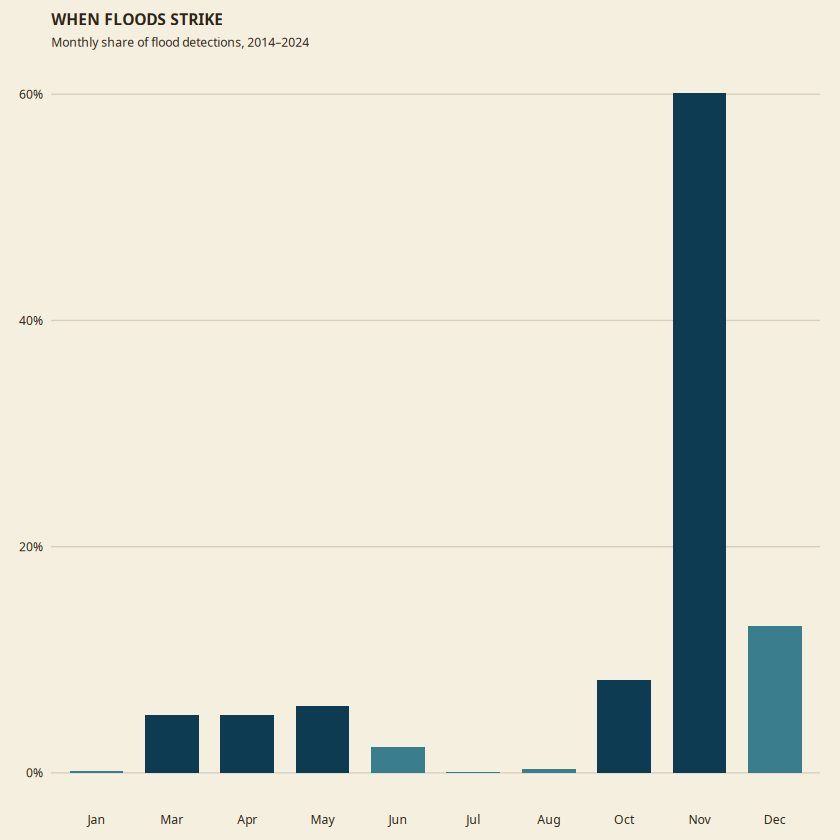

In [67]:
# 6. NEIGHBOURHOOD LABELS (Nairobi key areas)

# --- 6. NEIGHBOURHOOD LABELS (for annotation) ---
nairobi_labels <- tibble(
  name = c("Mathare","Kibera","Mukuru","Kawangware",
           "Korogocho","Ngong River Corridor","Nairobi CBD"),
  lon  = c(36.857, 36.779, 36.873, 36.738,
           36.882, 36.800, 36.820),
  lat  = c(-1.256, -1.312, -1.305, -1.283,
           -1.246, -1.335, -1.284)
)

labels_sf <- st_as_sf(nairobi_labels, coords = c("lon","lat"), crs = 4326)
labels_sf <- st_transform(labels_sf, 32737)


# 7. COMPUTE SUMMARY STATS FOR CALLOUTS

chronic_min_months <- 2      # threshold (tune as needed)

chronic_cells <- grid_polygons %>%
  filter(n_months >= chronic_min_months) %>%
  st_make_valid()

if (nrow(chronic_cells) == 0) {
  warning("No chronic/recurrent cells found. Lower the threshold or adjust filters.")
  chronic_union <- st_sfc(st_polygon(), crs = st_crs(grid_polygons))
} else {
  chronic_union <- chronic_cells %>%
    st_union() %>%
    st_make_valid()
}
pop_sf <- st_as_sf(pop_df, coords = c("lon","lat"), crs = 4326)
pop_sf <- st_transform(pop_sf, 32737)  # match chronic_union CRS

pop_in_chronic <- pop_sf %>%
  filter(lengths(st_intersects(geometry, chronic_union)) > 0) %>%
  pull(population) %>%
  sum(na.rm = TRUE)
# roads_flood_segments is the clipped, valid geometry in UTM
roads_risk_km <- roads_at_risk %>%
  st_length() %>%
  sum(na.rm = TRUE) %>%
  units::set_units("km") %>%
  as.numeric() %>%
  round(1)
total_events <- nrow(flood_filtered)
message(glue::glue(
  "People in chronic zones: ~{scales::comma(round(pop_in_chronic, -2))}\n",
  "Roads at risk: {roads_risk_km} km\n",
  "Total flood detections: {scales::comma(total_events)}"
))
# 8. SEASONALITY STRIP (monthly flood frequency)

season_df <- flood_filtered %>%
  count(month) %>%
  mutate(
    month_name = month.abb[month],
    month_name = factor(month_name, levels = month.abb),
    pct        = n / sum(n)
  )

plot_season <- ggplot(season_df, aes(x = month_name, y = pct)) +
  geom_col(fill = COL_FLOOD_MID, width = 0.7) +
  geom_col(
    data = season_df %>% filter(month %in% c(3, 4, 5, 10, 11)),
    fill = COL_FLOOD_HI, width = 0.7
  ) +
  scale_y_continuous(labels = scales::percent_format(accuracy = 1)) +
  labs(
    title    = "WHEN FLOODS STRIKE",
    subtitle = "Monthly share of flood detections, 2014–2024",
    x = NULL, y = NULL
  ) +
  theme_minimal(base_family = "sans") +
  theme(
    plot.background  = element_rect(fill = COL_BG, colour = NA),
    panel.background = element_rect(fill = COL_BG, colour = NA),
    panel.grid.major.x = element_blank(),
    panel.grid.minor   = element_blank(),
    panel.grid.major.y = element_line(colour = "#D9D0BC", linewidth = 0.3),
    plot.title    = element_text(size = 9,  face = "bold",  colour = COL_TEXT, hjust = 0),
    plot.subtitle = element_text(size = 7,  colour = COL_TEXT, hjust = 0),
    axis.text     = element_text(size = 7,  colour = COL_TEXT),
    plot.margin   = margin(8, 12, 8, 12)
  )
plot_season

## Final Analysis and Visualizations

<br>*Export a minimum of 2 visualizations (PDF, PNG or JPG). Each visualization should have a title, labeled x and y axis.* </br>

Relevant Lectures:
<br>**Course 3, Module 9**: "Helpful Data Visualizations for Data Cleaning and EDA" by JRS — Introduces helpful visualizations for EDA step.</br>
<br>**Course 5, Module 17**: "Data Visualizations and Communication" by Simon Queenborough — Discusses effective data visualization techniques.</br>



In [64]:
# 9. MAIN MAP

message("Building main map...")

# KDE density breaks — adjust after inspecting your data
# These quantile breaks define the contour ring thresholds
dens_breaks <- quantile(kde_df$density[kde_df$density > 0],
                        probs = c(0.60, 0.75, 0.88, 0.95, 0.99),
                        na.rm = TRUE)

main_map <- ggplot() +

  # --- Population density (warm amber glow beneath everything) ---
  geom_raster(
    data = pop_df,
    aes(x = lon, y = lat, fill = population),
    alpha = 0.55
  ) +
  scale_fill_gradient(
    low  = "transparent",
    high = COL_POP,
    na.value = "transparent",
    name = "Population/ndensity",
    guide = guide_colourbar(
      title.position = "top",
      barwidth = 0.5, barheight = 3,
      ticks = FALSE
    )
  ) +

  # --- Flood recurrence contour rings ---
  # (new scale so we use ggnewscale or manual approach)
  # We use stat_contour_filled on kde_df density
  new_scale_fill() +   # requires ggnewscale package
  stat_contour_filled(
    data    = kde_df,
    aes(x = lon, y = lat, z = density, fill = after_stat(level)),
    breaks  = c(0, dens_breaks),
    alpha   = 0.72
  ) +
  scale_fill_manual(
    values = c(
      "transparent",
      alpha(COL_FLOOD_LOW, 0.5),
      alpha(COL_FLOOD_MID, 0.6),
      alpha(COL_FLOOD_MID, 0.75),
      alpha(COL_FLOOD_HI,  0.85),
      alpha(COL_FLOOD_HI,  0.95)
    ),
    name   = "Flood recurrence/n(2014–2024)",
    labels = c("None", "Occasional", "", "High", "", "Chronic"),
    guide  = guide_legend(
      title.position = "top",
      override.aes   = list(alpha = 1)
    )
  ) +

  # --- Contour ring outlines (the "rings of risk" effect) ---
  stat_contour(
    data      = kde_df,
    aes(x = lon, y = lat, z = density),
    breaks    = dens_breaks,
    colour    = "white",
    linewidth = 0.25,
    alpha     = 0.6,
    linetype  = "solid"
  ) +

  # --- Roads — safe (outside flood zone) ---
  geom_sf(
    data      = roads_at_risk %>% filter(!in_flood_zone, road_class == "Major"),
    colour    = COL_ROAD,
    linewidth = 0.35,
    alpha     = 0.9
  ) +
  geom_sf(
    data      = roads_at_risk %>% filter(!in_flood_zone, road_class != "Major"),
    colour    = COL_ROAD,
    linewidth = 0.12,
    alpha     = 0.6
  ) +

  # --- Roads — AT RISK (inside flood zone) — rendered as dashed amber ---
  geom_sf(
    data      = roads_at_risk %>% filter(in_flood_zone, road_class == "Major"),
    colour    = COL_ROAD_RISK,
    linewidth = 0.5,
    linetype  = "dashed",
    alpha     = 1
  ) +
  geom_sf(
    data      = roads_at_risk %>% filter(in_flood_zone, road_class != "Major"),
    colour    = COL_ROAD_RISK,
    linewidth = 0.2,
    linetype  = "dashed",
    alpha     = 0.85
  ) +

  # --- Neighbourhood labels ---
  geom_label_repel(
    data         = nairobi_labels,
    aes(x = lon, y = lat, label = name),
    size         = 2.4,
    family       = "sans",
    colour       = COL_TEXT,
    fill         = alpha(COL_BG, 0.85),
    label.size   = 0,
    label.padding = unit(0.15, "lines"),
    segment.colour = COL_TEXT,
    segment.size = 0.3,
    min.segment.length = 0.2,
    box.padding  = 0.4,
    force        = 2,
    seed         = 42
  ) +

  # --- Map extent & coords ---
  coord_sf(
    xlim = c(nairobi_bbox["xmin"], nairobi_bbox["xmax"]),
    ylim = c(nairobi_bbox["ymin"], nairobi_bbox["ymax"]),
    expand = FALSE
  ) +

  # --- Scale bar & north arrow ---
  annotation_scale(
    location   = "bl",
    width_hint = 0.18,
    text_col   = COL_TEXT,
    line_col   = COL_TEXT,
    bar_cols   = c(COL_TEXT, COL_BG)
  ) +
  annotation_north_arrow(
    location = "bl",
    pad_x = unit(0.5, "cm"), pad_y = unit(0.7, "cm"),
    style = north_arrow_minimal(fill = COL_TEXT, line_col = COL_TEXT,
                                text_col = COL_TEXT, text_size = 7)
  ) +

  # --- Theme ---
  theme_void(base_family = "sans") +
  theme(
    plot.background  = element_rect(fill = COL_BG, colour = NA),
    panel.background = element_rect(fill = "#D6CCBA", colour = NA),
    legend.position  = c(0.02, 0.98),
    legend.justification = c(0, 1),
    legend.background = element_rect(fill = alpha(COL_BG, 0.85), colour = NA),
    legend.key.size   = unit(0.35, "cm"),
    legend.title      = element_text(size = 7,  face = "bold", colour = COL_TEXT),
    legend.text       = element_text(size = 6.5, colour = COL_TEXT),
    legend.margin     = margin(4, 6, 4, 6),
    legend.box.margin = margin(0, 0, 0, 0),
    plot.margin       = margin(0, 0, 0, 0)
  )

# 10. CALLOUT STAT BOXES

make_stat_box <- function(number, label, bg = COL_FLOOD_MID) {
  ggplot() +
    annotate("rect",
             xmin = 0, xmax = 1, ymin = 0, ymax = 1,
             fill = bg, colour = NA) +
    annotate("text",
             x = 0.5, y = 0.62, label = number,
             size = 7, fontface = "bold",
             colour = "white", family = "sans", hjust = 0.5) +
    annotate("text",
             x = 0.5, y = 0.25, label = label,
             size = 2.5, colour = "white",
             family = "sans", hjust = 0.5, lineheight = 1.1) +
    theme_void() +
    theme(plot.background = element_rect(fill = bg, colour = NA))
}

stat1 <- make_stat_box(
  scales::comma(round(pop_in_chronic, -3)),
  "people live inside/nchronic flood zones",
  bg = COL_FLOOD_HI
)

stat2 <- make_stat_box(
  as.character(roads_risk_km),
  "km of roads regularly/nunder flood threat",
  bg = COL_FLOOD_MID
)

stat3 <- make_stat_box(
  "10 yrs",
  "of Sentinel-1 SAR/nflood observations",
  bg = "#5C4033"
)

stats_row <- plot_grid(stat1, stat2, stat3, nrow = 1, rel_widths = c(1, 1, 1))

# 11. TITLE & SOURCE PANEL

title_panel <- ggplot() +
  theme_void() +
  theme(plot.background = element_rect(fill = COL_BG, colour = NA)) +
  annotate("text",
           x = 0.03, y = 0.80,
           label = "RINGS OF RISK",
           size = 11, fontface = "bold",
           colour = COL_TEXT, family = "sans", hjust = 0) +
  annotate("text",
           x = 0.03, y = 0.52,
           label = "Nairobi's flood hotspots and the walking routes they sever",
           size = 5, colour = COL_TEXT, family = "sans", hjust = 0) +
  annotate("text",
           x = 0.03, y = 0.28,
           label = paste0(
             "Contour rings show where flooding has been detected repeatedly over 10 years (2014–2024) ",
             "using cloud-penetrating/nSentinel-1 SAR satellite data. Amber dashed lines are road segments ",
             "falling inside high or chronic flood zones —/nroutes on which pedestrians and cyclists depend ",
             "daily, with no dedicated infrastructure to protect them."
           ),
           size = 2.8, colour = COL_TEXT, family = "sans", hjust = 0,
           lineheight = 1.35) +
  annotate("text",
           x = 0.03, y = 0.05,
           label = paste0(
             "Sources: AI for Good Lab / Microsoft Flood Dataset (Nature Communications, 2025)  •  ",
             "OpenStreetMap  •  WorldPop Kenya 2020/n",
             "Methodology: Flood detections filtered for false positives (slope, soil moisture, temperature, land cover). ",
             "KDE weighted by recurrence months. All roads assumed to carry pedestrian & cyclist traffic."
           ),
           size = 2.2, colour = alpha(COL_TEXT, 0.65),
           family = "sans", hjust = 0, lineheight = 1.3) +
  xlim(0, 1) + ylim(0, 1)

# 12. LEGEND STRIP — road types

road_legend <- ggplot() +
  theme_void() +
  theme(plot.background = element_rect(fill = COL_BG, colour = NA)) +
  annotate("segment",
           x = 0.05, xend = 0.22, y = 0.65, yend = 0.65,
           colour = COL_ROAD, linewidth = 0.8) +
  annotate("text",
           x = 0.25, y = 0.65, label = "Road — no flood risk",
           size = 2.6, colour = COL_TEXT, hjust = 0) +
  annotate("segment",
           x = 0.05, xend = 0.22, y = 0.35, yend = 0.35,
           colour = COL_ROAD_RISK, linewidth = 0.8, linetype = "dashed") +
  annotate("text",
           x = 0.25, y = 0.35, label = "Road — inside flood zone",
           size = 2.6, colour = COL_TEXT, hjust = 0) +
  xlim(0, 1) + ylim(0, 1)

# 13. ASSEMBLE FULL POSTER

message("Assembling poster...")

# Require ggnewscale for dual fill scales in main map
# install.packages("ggnewscale") if not present

top_panel    <- plot_grid(title_panel, road_legend,
                          nrow = 1, rel_widths = c(3, 1))
bottom_panel <- plot_grid(stats_row, plot_season,
                          nrow = 1, rel_widths = c(1.2, 1))

full_poster <- plot_grid(
  top_panel,
  main_map,
  bottom_panel,
  ncol        = 1,
  rel_heights = c(0.18, 0.62, 0.20)
)

# 14. SAVE

output_path <- "outputs/rings_of_risk_nairobi.png"
message(glue::glue("Saving to {output_path}..."))

ggsave(
  filename = output_path,
  plot     = full_poster,
  width    = 14,
  height   = 17,
  dpi      = 300,
  bg       = COL_BG
)

message("Done! Open rings_of_risk_nairobi.png")


# APPENDIX: PACKAGE INSTALL BLOCK (run once before the script above)

# install.packages(c(
#   "tidyverse", "sf", "terra", "osmdata", "MASS",
#   "scales", "patchwork", "ggspatial", "ggrepel",
#   "cowplot", "arrow", "ggnewscale", "glue", "units"
# ))
#
# WorldPop download:
#   https://hub.worldpop.org/geodata/listing?id=29786
#   → Kenya 2020, unconstrained, 100m: KEN_ppp_v2b_2020_UNadj.tif
#
# Flood tile:
#   https://huggingface.co/datasets/ai-for-good-lab/ai4g-flood-dataset/tree/main
#   → Folder: S03/S03E036/
#   → Files needed:
#       S03E036-post-processing.parquet
#       S03E036-recurrence-80m-buffer.tif


Building main map...



Assembling poster...



Saving to outputs/rings_of_risk_nairobi.png...



Done! Open rings_of_risk_nairobi.png



Building main map...



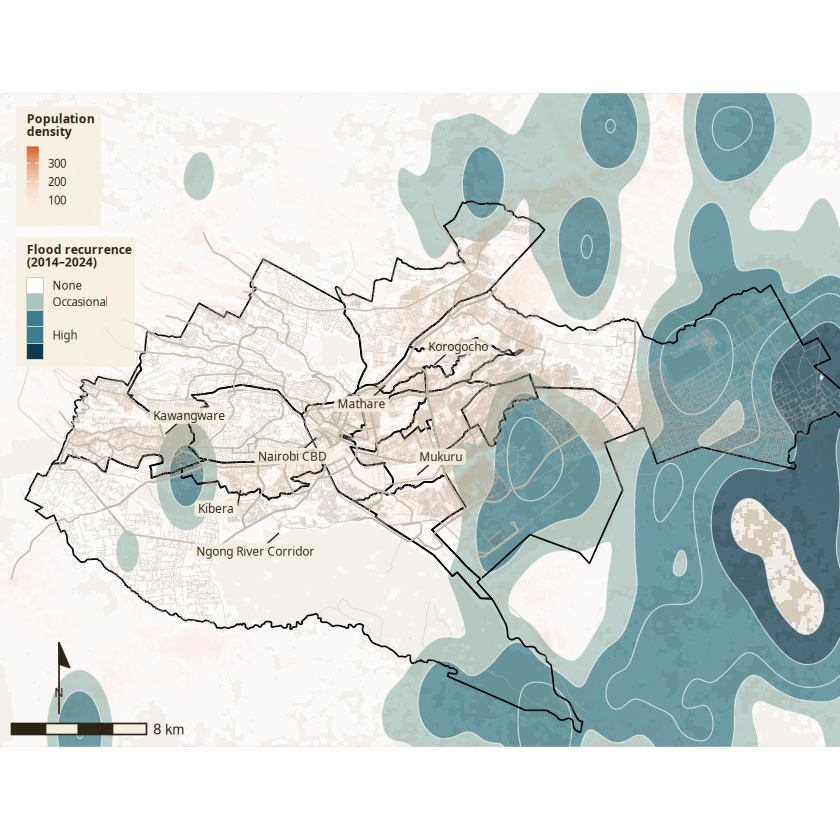

In [71]:
# =========================
# 9. MAIN MAP (robust)
# =========================
library(ggplot2)
library(dplyr)
library(ggnewscale)
library(ggrepel)
library(ggspatial)
library(sf)

message("Building main map...")

# ---- 9.0 Ensure plotting layers (roads) are in WGS84 for the map ----
if (!exists("roads_at_risk_wgs")) {
  stopifnot(inherits(roads_at_risk, "sf"))
  roads_at_risk_wgs <- sf::st_transform(roads_at_risk, 4326)
}
if (exists("roads_flood_segments") && !exists("roads_flood_segments_wgs")) {
  roads_flood_segments_wgs <- sf::st_transform(roads_flood_segments, 4326)
}

# ---- 9.1 KDE density breaks with a safe fallback ----
dens_vec <- kde_df$density
dens_vec <- dens_vec[is.finite(dens_vec) & dens_vec > 0]

if (length(dens_vec) >= 10) {
  dens_breaks <- stats::quantile(
    dens_vec, probs = c(0.60, 0.75, 0.88, 0.95, 0.99), na.rm = TRUE
  )
} else if (length(dens_vec) > 0) {
  dens_breaks <- stats::quantile(
    dens_vec, probs = c(0.50, 0.70, 0.85, 0.95), na.rm = TRUE
  )
} else {
  dens_breaks <- c(1e-9, 2e-9, 3e-9, 4e-9)  # renders “nothing” but avoids errors
  warning("KDE density appears empty; contour rings may not render.")
}

# ---- 9.2 Prefer clipped flooded segments if available ----
use_segments <- exists("roads_flood_segments_wgs") &&
                inherits(roads_flood_segments_wgs, "sf") &&
                nrow(roads_flood_segments_wgs) > 0

# ---- 9.3 Build the map ----
main_map <- ggplot() +

  # --- Population density (warm amber glow beneath everything) ---
  geom_raster(
    data = pop_df,
    aes(x = lon, y = lat, fill = population),
    alpha = 0.65
  ) +
  scale_fill_gradient(
    low  = "transparent",
    high = COL_POP,
    na.value = "transparent",
    name = "Population\ndensity",    # <-- fixed line break
    guide = guide_colourbar(
      title.position = "top",
      barwidth = 0.5, barheight = 3,
      ticks = FALSE
    )
  ) +

  # --- Flood recurrence contour rings (KDE) ---
  ggnewscale::new_scale_fill() +
  stat_contour_filled(
    data    = kde_df,
    aes(x = lon, y = lat, z = density, fill = after_stat(level)),
    breaks  = c(0, dens_breaks),
    alpha   = 0.72
  ) +
  scale_fill_manual(
    values = c(
      "transparent",
      alpha(COL_FLOOD_LOW, 0.5),
      alpha(COL_FLOOD_MID, 0.6),
      alpha(COL_FLOOD_MID, 0.75),
      alpha(COL_FLOOD_HI,  0.85),
      alpha(COL_FLOOD_HI,  0.95)
    ),
    name   = "Flood recurrence\n(2014–2024)",  # <-- fixed line break
    labels = c("None", "Occasional", "", "High", "", "Chronic"),
    guide  = guide_legend(
      title.position = "top",
      override.aes   = list(alpha = 1)
    )
  ) +

  # --- Contour ring outlines (the "rings of risk" effect) ---
  stat_contour(
    data      = kde_df,
    aes(x = lon, y = lat, z = density),
    breaks    = dens_breaks,
    colour    = "white",
    linewidth = 0.25,
    alpha     = 0.6,
    linetype  = "solid"
  ) +

  # --- Roads — safe (outside flood zone) ---
  geom_sf(
    data      = subcounties,
    colour    = "black",
    linewidth = 0.35,
    alpha     = 0
  ) + geom_sf(
    data      = roads_at_risk_wgs %>% dplyr::filter(!in_flood_zone, road_class == "Major"),
    colour    = COL_ROAD,
    linewidth = 0.35,
    alpha     = 0.9
  ) +
  geom_sf(
    data      = roads_at_risk_wgs %>% dplyr::filter(!in_flood_zone, road_class != "Major"),
    colour    = COL_ROAD,
    linewidth = 0.12,
    alpha     = 0.6
  ) +

  # --- Roads — AT RISK (inside flood zone), dashed amber ---
  {
    if (use_segments) {
      list(
        geom_sf(
          data      = roads_flood_segments_wgs %>% dplyr::filter(road_class == "Major"),
          colour    = COL_ROAD_RISK,
          linewidth = 0.5,
          linetype  = "dashed",
          alpha     = 1
        ),
        geom_sf(
          data      = roads_flood_segments_wgs %>% dplyr::filter(road_class != "Major"),
          colour    = COL_ROAD_RISK,
          linewidth = 0.2,
          linetype  = "dashed",
          alpha     = 0.85
        )
      )
    } else {
      list(
        geom_sf(
          data      = roads_at_risk_wgs %>% dplyr::filter(in_flood_zone, road_class == "Major"),
          colour    = COL_ROAD_RISK,
          linewidth = 0.5,
          linetype  = "dashed",
          alpha     = 1
        ),
        geom_sf(
          data      = roads_at_risk_wgs %>% dplyr::filter(in_flood_zone, road_class != "Major"),
          colour    = COL_ROAD_RISK,
          linewidth = 0.2,
          linetype  = "dashed",
          alpha     = 0.85
        )
      )
    }
  } +

  # --- Neighbourhood labels ---
  ggrepel::geom_label_repel(
    data           = nairobi_labels,     # tibble with lon/lat/name in EPSG:4326
    aes(x = lon, y = lat, label = name),
    size           = 2.4,
    family         = "sans",
    colour         = COL_TEXT,
    fill           = alpha(COL_BG, 0.85),
    label.size     = 0,
    label.padding  = unit(0.15, "lines"),
    segment.colour = COL_TEXT,
    segment.size   = 0.3,
    min.segment.length = 0.2,
    box.padding    = 0.4,
    force          = 2,
    seed           = 42
  ) +

  # --- Map extent & coords (WGS84) ---
  coord_sf(
    xlim = c(nairobi_bbox["xmin"], nairobi_bbox["xmax"]),
    ylim = c(nairobi_bbox["ymin"], nairobi_bbox["ymax"]),
    expand = FALSE
  ) +

  # --- Scale bar & north arrow ---
  ggspatial::annotation_scale(
    location   = "bl",
    width_hint = 0.18,
    text_col   = COL_TEXT,
    line_col   = COL_TEXT,
    bar_cols   = c(COL_TEXT, COL_BG)
  ) +
  ggspatial::annotation_north_arrow(
    location = "bl",
    pad_x = unit(0.5, "cm"), pad_y = unit(0.7, "cm"),
    style = ggspatial::north_arrow_minimal(
      fill = COL_TEXT, line_col = COL_TEXT, text_col = COL_TEXT, text_size = 7
    )
  ) +

  # --- Theme ---
  theme_void(base_family = "sans") +
  theme(
    plot.background  = element_rect(fill = COL_BG, colour = NA),
    panel.background = element_rect(fill = "#D6CCBA", colour = NA),
    legend.position  = c(0.02, 0.98),
    legend.justification = c(0, 1),
    legend.background = element_rect(fill = alpha(COL_BG, 0.85), colour = NA),
    legend.key.size   = unit(0.35, "cm"),
    legend.title      = element_text(size = 7,  face = "bold", colour = COL_TEXT),
    legend.text       = element_text(size = 6.5, colour = COL_TEXT),
    legend.margin     = margin(4, 6, 4, 6),
    legend.box.margin = margin(0, 0, 0, 0),
    plot.margin       = margin(0, 0, 0, 0)
  )
main_map

## Ethical Considerations
- Privacy: The dataset does not contain personal data.
- Governance: Data used is openly available and ethically sourced.
- Bias: Consideration of potential biases in dataset and analysis.

## Acknowledging Limitations
*In 1-2 sentences, acknowledge any limitations of your data or analysis.*

Relevant Lectures:
<br>**Course 3, Module 8**: "Handling Data Anomalies" by Angel — Discusses how to handle data anomalies and understand the limitations of your data.</br>

The analysis is based on the `mpg` dataset, which may have limitations such as:
- Limited scope: Only includes data available and may not capture the entire spectrum of vehicle data.
- Data quality: Possible measurement errors or missing values.

## Results for Non-Technical Audience
*In 1-2 sentences, explain the results of your analysis to a non-technical audience and the implications of your results for your environmental topic.*

Relevant Lectures:
<br>**Course 5, Module 15**: "Turning Data into Action" by Denice Ross — Discusses strategies for communicating results to a non-technical audience.</br>

Fuel economy varies significantly across different vehicle classes. Smaller and more efficient engines generally achieve higher miles per gallon (MPG) on the highway. Manufacturers show varying performance in terms of fuel economy, with some focusing on more efficient vehicles.

## Instructions for Reproducing Project
*Describe the steps someone else would need to take to reproduce your project.*
Relevant Lectures:
<br>**Course 2, Module 6**: "Addressing Version Control and Reproducibility" by Mitch — Explains the importance and strategies for version control.</br>
<br>**Course 4, Module 14**: "Creating Data Visualizations for EDA" by JRS — Provides guidance on reproducible EDA practices.</br>

1. Clone the GitHub repository.
2. Ensure you have R and the required libraries installed (`dplyr`, `ggplot2`).
3. Open and run the provided Jupyter notebook.